[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



📊 Classification Report (Without Feature Selection):
              precision    recall  f1-score   support

           0       0.36      0.48      0.41        42
           1       0.06      0.01      0.02       107
           2       0.72      0.69      0.70      1209
           3       0.50      0.61      0.55       632
           4       0.00      0.00      0.00        10

    accuracy                           0.62      2000
   macro avg       0.33      0.36      0.34      2000
weighted avg       0.60      0.62      0.61      2000

🧾 Confusion Matrix for CNB (No Feature Selection):
 [[ 20   0   9  13   0]
 [  8   1  74  24   0]
 [ 19  11 833 346   0]
 [  6   3 239 384   0]
 [  2   1   3   4   0]]


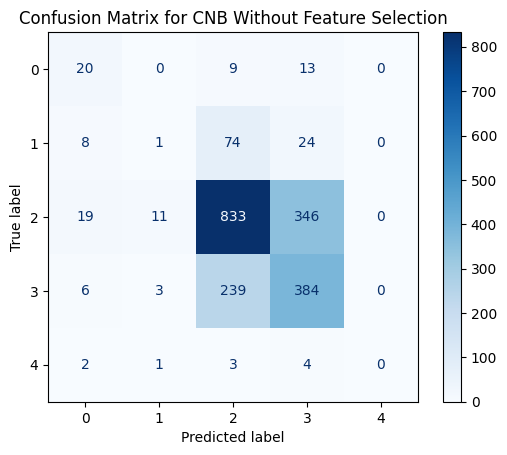

 FORWARD SELECTION STARTED
Added: tfidf (F1 = 0.2758)
Added: year (F1 = 0.3233)
Added: genres (F1 = 0.3346)

 Final selected features: ['tfidf', 'year', 'genres']

 Classification Report (Forward Selection):
              precision    recall  f1-score   support

           0       0.36      0.50      0.42        42
           1       0.06      0.01      0.02       107
           2       0.72      0.69      0.71      1209
           3       0.50      0.61      0.55       632
           4       0.00      0.00      0.00        10

    accuracy                           0.62      2000
   macro avg       0.33      0.36      0.34      2000
weighted avg       0.61      0.62      0.61      2000

🧾 Confusion Matrix For CNB:
 [[ 21   0   8  13   0]
 [ 10   1  73  23   0]
 [ 20  12 834 343   0]
 [  6   3 238 385   0]
 [  2   1   3   4   0]]


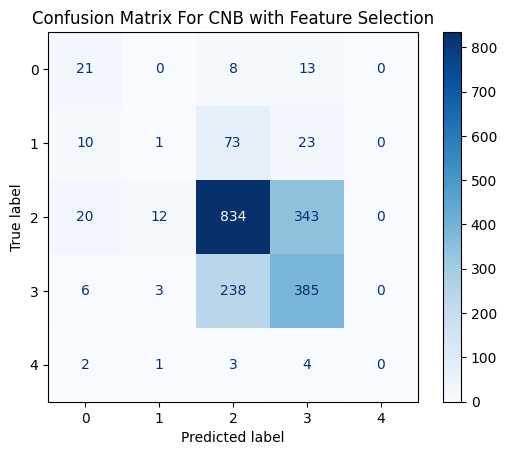

In [ ]:
############################################################

# COMPLEMENT NAIVE BAYES CODE


################################################################

import numpy as np
import pandas as pd
import string
from sklearn.preprocessing import MinMaxScaler, MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from scipy.sparse import hstack, csr_matrix
import nltk
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# Downloads (comment out if already done)
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

# Load dataset
df = pd.read_csv('./imdb_movies.csv')
df = df[df['orig_lang'].apply(lambda x: x.isascii())]
df = df.drop_duplicates(subset=['names', 'date_x'])
df['release_date'] = pd.to_datetime(df['date_x'], errors='coerce')
df['release_year'] = df['release_date'].dt.year.fillna(0).astype(int)

df['budget_x'] = pd.to_numeric(df['budget_x'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['budget_normalized'] = MinMaxScaler().fit_transform(df[['budget_x']].fillna(0))
df['revenue_normalized'] = MinMaxScaler().fit_transform(df[['revenue']].fillna(0))

df['genre_list'] = df['genre'].fillna('').apply(lambda x: [g.strip() for g in x.split(',')])


def map_rating(score):
    if pd.isna(score): return np.nan
    score = float(score)
    if score < 30:
        return 0
    elif score < 50:
        return 1
    elif score < 70:
        return 2
    elif score < 85:
        return 3
    else:
        return 4


df['rating_class'] = df['score'].apply(map_rating)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))


def clean_text(text: str):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = ''.join([char for char in text if char.isascii() and char not in string.punctuation])
    tokens = word_tokenize(text)
    lemmatized = [lemmatizer.lemmatize(word) for word in tokens if word.isalpha() and word not in stop_words]
    return " ".join(lemmatized)


df['clean_overview'] = df['overview'].apply(clean_text)

tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_overview'])

mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(df['genre_list'])
genre_sparse = csr_matrix(genre_matrix)

budget_sparse = csr_matrix(df[['budget_normalized']].fillna(0).values)
revenue_sparse = csr_matrix(df[['revenue_normalized']].fillna(0).values)

df['release_date'] = pd.to_datetime(df['date_x'], errors='coerce')
df['release_year'] = df['release_date'].dt.year.fillna(0).astype(int)
year_encoded = pd.get_dummies(df['release_year'], prefix='year')
year_sparse = csr_matrix(year_encoded.values)

valid_rows = df['rating_class'].notna().to_numpy()
df_valid = df.loc[valid_rows].reset_index(drop=True)

X_tfidf_valid = X_tfidf[valid_rows]
genre_sparse_valid = genre_sparse[valid_rows]
budget_sparse_valid = budget_sparse[valid_rows]
revenue_sparse_valid = revenue_sparse[valid_rows]
year_sparse_valid = year_sparse[valid_rows]

y = df_valid['rating_class']


# === FORWARD SELECTION ===

# 2. Stack all features into one matrix
X = hstack([
    X_tfidf_valid,
    genre_sparse_valid,
    budget_sparse_valid,
    revenue_sparse_valid,
    year_sparse_valid
])

from sklearn.naive_bayes import ComplementNB

# Use the full feature set (before selection)
# Replace X_full_combined with your full feature matrix variable (e.g., X_combined)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define and train the CNB model
model = OneVsRestClassifier(ComplementNB())
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Print classification report
print("\n Classification Report (Without Feature Selection):")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("🧾 Confusion Matrix for CNB (No Feature Selection):\n", cm)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for CNB Without Feature Selection")
plt.show()
from sklearn.naive_bayes import ComplementNB


feature_blocks = {
    'tfidf': X_tfidf_valid,
    'genres': genre_sparse_valid,
    'budget': budget_sparse_valid,
    'revenue': revenue_sparse_valid,
    'year': year_sparse_valid
}

selected = []
remaining = list(feature_blocks.keys())
best_score = 0

print(" FORWARD SELECTION STARTED")
while remaining:
    scores = []
    for feat in remaining:
        X_try = hstack([feature_blocks[f] for f in selected + [feat]])
        score = cross_val_score(
            OneVsRestClassifier(ComplementNB()),
            X_try, y, cv=3, scoring='f1_macro'
        ).mean()
        scores.append((feat, score))

    best_feat, best_feat_score = max(scores, key=lambda x: x[1])
    if best_feat_score > best_score:
        selected.append(best_feat)
        remaining.remove(best_feat)
        best_score = best_feat_score
        print(f"Added: {best_feat} (F1 = {best_feat_score:.4f})")
    else:
        break

print(f"\n Final selected features: {selected}")

X_selected = hstack([feature_blocks[f] for f in selected])
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

model = OneVsRestClassifier(ComplementNB())
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\n Classification Report (Forward Selection):")
print(classification_report(y_test, y_pred))


# Assuming it's a single-label multi-class task (not multilabel)
cm = confusion_matrix(y_test, y_pred)
print("🧾 Confusion Matrix For CNB:\n", cm)

# Optional: display with labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix For CNB with Feature Selection")
plt.show()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


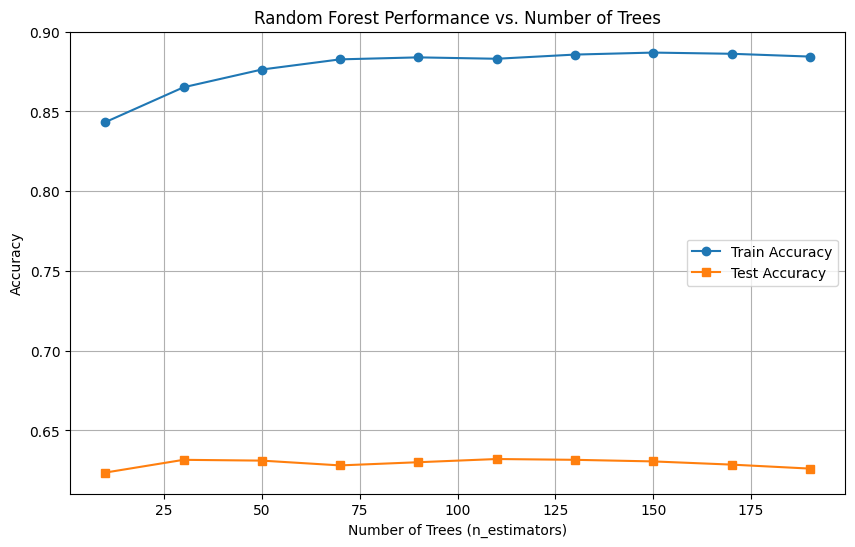

Mean CV Accuracy: 0.6235
Mean CV Error: 0.3765

 Final Test Set Classification Report: before Feature Selection
              precision    recall  f1-score   support

           0       1.00      0.19      0.32        42
           1       0.00      0.00      0.00       107
           2       0.63      0.96      0.76      1209
           3       0.62      0.14      0.23       632
           4       0.00      0.00      0.00        10

    accuracy                           0.63      2000
   macro avg       0.45      0.26      0.26      2000
weighted avg       0.60      0.63      0.54      2000

 FORWARD FEATURE SELECTION — Random Forest
 Added: revenue (F1 = 0.5210)
 Added: budget (F1 = 0.5611)
No improvement — stopping selection.

 Final selected features: ['revenue', 'budget']

 Classification Report (Forward Selection + Random Forest):
              precision    recall  f1-score   support

           0       0.92      0.86      0.89        42
           1       0.77      0.35      0.

In [ ]:
############################################################

# Random Forest Code



################################################################



import numpy as np
import pandas as pd
import string
from sklearn.preprocessing import MinMaxScaler, MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from scipy.sparse import hstack, csr_matrix
import nltk
from sklearn.preprocessing import MultiLabelBinarizer
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from scipy.sparse import hstack

# Downloads (comment out if already done)
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

# Load dataset
df = pd.read_csv('./imdb_movies.csv')

# Drop non-ASCII languages elements 
df = df[df['orig_lang'].apply(lambda x: x.isascii())]

# Drop duplicates rows 
df = df.drop_duplicates(subset=['names', 'date_x'])

# Convert date and extract year
df['release_date'] = pd.to_datetime(df['date_x'], errors='coerce')
df['release_year'] = df['release_date'].dt.year.fillna(0).astype(int)

# Normalize numeric features
df['budget_x'] = pd.to_numeric(df['budget_x'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['budget_normalized'] = MinMaxScaler().fit_transform(df[['budget_x']].fillna(0))
df['revenue_normalized'] = MinMaxScaler().fit_transform(df[['revenue']].fillna(0))

# Process genre list and convert the comma delimited genres into an array of words 
df['genre_list'] = df['genre'].fillna('').apply(lambda x: [g.strip() for g in x.split(',')])

# Bin the rating into classes discretization
def map_rating(score):
    if pd.isna(score): return np.nan
    score = float(score)
    if score < 30: return 0
    elif score < 50: return 1
    elif score < 70: return 2
    elif score < 85: return 3
    else: return 4

# apply the discretization to the dataframe
df['rating_class'] = df['score'].apply(map_rating)

# Clean and lemmatize overview text
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))


# cleans up the words for the movie overview descripton and lemmatizes it for more efficient processing 
def clean_text(text: str):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = ''.join([char for char in text if char.isascii() and char not in string.punctuation])
    tokens = word_tokenize(text)
    lemmatized = [lemmatizer.lemmatize(word) for word in tokens if word.isalpha() and word not in stop_words]
    return " ".join(lemmatized)

df['clean_overview'] = df['overview'].apply(clean_text)

 # Vectorize the movie description using TF-IDF; turns text like "hero saves world" => [0.21, 0.00, 0.45, ...] across 5000 word features
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_overview'])


# One-hot encode the genre list so each genre becomes a binary column
# e.g., ['Action', 'Comedy'] => [1, 0, 1, 0] for ['Action', 'Adventure', 'Comedy', 'Drama']
mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(df['genre_list'])
genre_sparse = csr_matrix(genre_matrix)

# Convert normalized budget and revenue into sparse format for efficient stacking
# e.g., budget 0.45 => [0.45], revenue 0.88 => [0.88]
budget_sparse = csr_matrix(df[['budget_normalized']].fillna(0).values)
revenue_sparse = csr_matrix(df[['revenue_normalized']].fillna(0).values)


# Extract release year from date and one-hot encode it
# e.g., year 2020 => [0, 0, 1, 0] for ['year_2018', 'year_2019', 'year_2020', 'year_2021']

df['release_date'] = pd.to_datetime(df['date_x'], errors='coerce')
df['release_year'] = df['release_date'].dt.year.fillna(0).astype(int)

year_encoded = pd.get_dummies(df['release_year'], prefix='year')
year_sparse = csr_matrix(year_encoded.values)


# Filter rows with valid labels
valid_rows = df['rating_class'].notna().to_numpy()
df_valid = df.loc[valid_rows].reset_index(drop=True)

# Filter out rows with missing target labels so model only trains on complete data
# Then apply the same mask to each feature matrix to keep everything aligned row-wise
X_tfidf_valid = X_tfidf[valid_rows]
genre_sparse_valid = genre_sparse[valid_rows]
budget_sparse_valid = budget_sparse[valid_rows]
revenue_sparse_valid = revenue_sparse[valid_rows]
lang_sparse_valid = revenue_sparse[valid_rows]
year_sparse_valid = year_sparse[valid_rows]

# 2. Stack all features into one matrix
X = hstack([
    X_tfidf_valid,
    genre_sparse_valid,
    budget_sparse_valid,
    revenue_sparse_valid,
    lang_sparse_valid,
    year_sparse_valid
])

# 3. Define target variable
y = df_valid['rating_class']


# Reduce TF-IDF dimensionality from 5000 → 200 (for example)
svd = TruncatedSVD(n_components=200, random_state=42)
X_tfidf_reduced = svd.fit_transform(X_tfidf_valid)

# Convert other sparse parts to dense
genre_dense = genre_sparse_valid.toarray()
budget_dense = budget_sparse_valid.toarray()
revenue_dense = revenue_sparse_valid.toarray()
year_dense = year_sparse_valid.toarray()

lang_encoded = pd.get_dummies(df['orig_lang'], prefix='lang')
lang_sparse = csr_matrix(lang_encoded.values)
lang_dense = lang_sparse[valid_rows].toarray()
from sklearn.model_selection import cross_val_predict,cross_val_score
from sklearn.metrics import classification_report


# Combine all features into a single dense matrix
X_combined = np.hstack([
    X_tfidf_reduced.toarray() if hasattr(X_tfidf_reduced, "toarray") else X_tfidf_reduced,
    genre_dense,
    budget_dense,
    revenue_dense,
    lang_dense,
    year_dense
])



# Try different numbers of trees
n_estimators_list = list(range(10, 210, 20))
train_accuracies = []
test_accuracies = []
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)

for n in n_estimators_list:
    model = RandomForestClassifier(
    n_estimators=n,
    max_depth=15,
    min_samples_leaf=4,        
    random_state=42,
    n_jobs=-1
)

    model.fit(X_train, y_train)

    # Accuracy on training data
    train_acc = accuracy_score(y_train, model.predict(X_train))
    train_accuracies.append(train_acc)

    # Accuracy on test data
    test_acc = accuracy_score(y_test, model.predict(X_test))
    test_accuracies.append(test_acc)

# Plot the error/accuracy curve
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_list, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(n_estimators_list, test_accuracies, label='Test Accuracy', marker='s')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.title('Random Forest Performance vs. Number of Trees')
plt.legend()
plt.grid(True)
plt.show()


# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)

# Define the model (we found out that before the best tree value is 100)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)



# Perform cross-validation on the training set (optional, for internal validation)
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Mean CV Error: {1 - cv_scores.mean():.4f}")

# Train final model on full training set
rf_model.fit(X_train, y_train)

# Predict on the test set
y_test_pred = rf_model.predict(X_test)

# Generate test set classification report
print("\n Final Test Set Classification Report: before Feature Selection")
print(classification_report(y_test,y_test_pred))


# define all the features and conduct forward selection
feature_blocks = {
    'tfidf': X_tfidf_valid,
    'genres': genre_sparse_valid,
    'budget': budget_sparse_valid,
    'revenue': revenue_sparse_valid,
    'year': year_sparse_valid
}

selected = []
remaining = list(feature_blocks.keys())
best_score = 0

print(" FORWARD FEATURE SELECTION — Random Forest")
while remaining:
    scores = []
    for feat in remaining:
        # Try adding each remaining feature block
        X_try = hstack([feature_blocks[f] for f in selected + [feat]])
        
        # Convert to dense for Random Forest
        X_try_dense = X_try.toarray() if hasattr(X_try, "toarray") else X_try
        
        # Evaluate using cross-validation
        score = cross_val_score(
            RandomForestClassifier(
                n_estimators=100,
                max_depth=15,
                min_samples_leaf=4,
                random_state=42,
                n_jobs=-1
            ),
            X_try_dense,
            y,
            cv=3,
            scoring='f1_macro'
        ).mean()
        
        scores.append((feat, score))

    best_feat, best_feat_score = max(scores, key=lambda x: x[1])
    if best_feat_score > best_score:
        selected.append(best_feat)
        remaining.remove(best_feat)
        best_score = best_feat_score
        print(f" Added: {best_feat} (F1 = {best_feat_score:.4f})")
    else:
        print("No improvement — stopping selection.")
        break

print(f"\n Final selected features: {selected}")

# select only the features determined by forward selection
X_selected = hstack([feature_blocks[f] for f in selected])

# split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)


# Define the Random Forest model (set n estimator to 100 based on analysis of graph)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

# Train and predict
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

# Output classification report
print("\n Classification Report (Forward Selection + Random Forest):")
print(classification_report(y_test, y_pred))




[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
  File "c:\Users\russm\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\russm\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 556, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\russm\AppData\Local\Program

Movie Name: Rings
Release Date: 05/31/2017 
Genres: ['Horror']
Budget: 25000000.0
Revenue: 82917283.0
Overview: Julia becomes worried about her boyfriend Holt when he explores the dark urban legend of a mysterious videotape said to kill the watcher seven days after viewing. She sacrifices herself to save her bo ...
Actual Rating Class: 2
Predicted Rating Class: 2

Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.60      0.53        42
           1       0.33      0.04      0.07       107
           2       0.67      0.86      0.75      1209
           3       0.58      0.34      0.43       632
           4       0.00      0.00      0.00        10

    accuracy                           0.64      2000
   macro avg       0.41      0.37      0.35      2000
weighted avg       0.61      0.64      0.60      2000



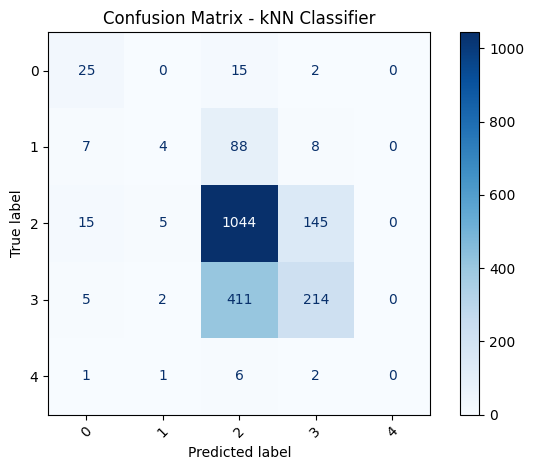

In [ ]:
############################################################

# K-Nearest-Neighbors (WITHOUT FORWARD SELECTION)



################################################################
import numpy as np
import pandas as pd
import string
from sklearn.preprocessing import MinMaxScaler, MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from scipy.sparse import hstack, csr_matrix
import nltk
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

# Downloads (comment out if already done)
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

# Load dataset
df = pd.read_csv('./imdb_movies.csv')
df = df[df['orig_lang'].apply(lambda x: x.isascii())]
df = df.drop_duplicates(subset=['names', 'date_x'])

df['release_date'] = pd.to_datetime(df['date_x'], errors='coerce')
df['release_year'] = df['release_date'].dt.year.fillna(0).astype(int)

df['budget_x'] = pd.to_numeric(df['budget_x'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['budget_normalized'] = MinMaxScaler().fit_transform(df[['budget_x']].fillna(0))
df['revenue_normalized'] = MinMaxScaler().fit_transform(df[['revenue']].fillna(0))

df['genre_list'] = df['genre'].fillna('').apply(lambda x: [g.strip() for g in x.split(',')])

def map_rating(score):
    if pd.isna(score): return np.nan
    score = float(score)
    if score < 30: return 0
    elif score < 50: return 1
    elif score < 70: return 2
    elif score < 85: return 3
    else: return 4

df['rating_class'] = df['score'].apply(map_rating)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text: str):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = ''.join([char for char in text if char.isascii() and char not in string.punctuation])
    tokens = word_tokenize(text)
    lemmatized = [lemmatizer.lemmatize(word) for word in tokens if word.isalpha() and word not in stop_words]
    return " ".join(lemmatized)

df['clean_overview'] = df['overview'].apply(clean_text)

tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_overview'])

mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(df['genre_list'])
genre_sparse = csr_matrix(genre_matrix)

budget_sparse = csr_matrix(df[['budget_normalized']].fillna(0).values)
revenue_sparse = csr_matrix(df[['revenue_normalized']].fillna(0).values)

df['release_date'] = pd.to_datetime(df['date_x'], errors='coerce')
df['release_year'] = df['release_date'].dt.year.fillna(0).astype(int)
year_encoded = pd.get_dummies(df['release_year'], prefix='year')
year_sparse = csr_matrix(year_encoded.values)

valid_rows = df['rating_class'].notna().to_numpy()
df_valid = df.loc[valid_rows].reset_index(drop=True)

X_tfidf_valid = X_tfidf[valid_rows]
genre_sparse_valid = genre_sparse[valid_rows]
budget_sparse_valid = budget_sparse[valid_rows]
revenue_sparse_valid = revenue_sparse[valid_rows]
year_sparse_valid = year_sparse[valid_rows]
y = df_valid['rating_class']

# Combine features
X = hstack([
    X_tfidf_valid,
    genre_sparse_valid,
    budget_sparse_valid,
    revenue_sparse_valid,
    year_sparse_valid
])

# Split data
all_indices = np.arange(X.shape[0])
X_dense = X.toarray()  # KNN requires dense input

X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X_dense, y, all_indices, test_size=0.2, random_state=42
)

# KNN Classifier
knn_model = KNeighborsClassifier(n_neighbors=9, metric='euclidean')
knn_model.fit(X_train, y_train)

# Predict
y_pred = knn_model.predict(X_test)

# Inspect a sample
i = 10
original_index = test_idx[i]
movie = df_valid.iloc[original_index]

print("Movie Name:", movie['names'])
print("Release Date:", movie['date_x'])
print("Genres:", movie['genre_list'])
print("Budget:", movie['budget_x'])
print("Revenue:", movie['revenue'])
print("Overview:", movie['overview'][:200], "...")
print("Actual Rating Class:", y_test.iloc[i])
print("Predicted Rating Class:", y_pred[i])

# Evaluation
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_model.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - kNN Classifier")
plt.tight_layout()
plt.show()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Movie Name: Rings
Release Date: 05/31/2017 
Genres: ['Horror']
Budget: 25000000.0
Revenue: 82917283.0
Overview: Julia becomes worried about her boyfriend Holt when he explores the dark urban legend of a mysterious videotape said to kill the watcher seven days after viewing. She sacrifices herself to save her bo ...
Actual Rating Class: 2
Predicted Rating Class: 2

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.36      0.43        42
           1       0.20      0.04      0.06       107
           2       0.67      0.84      0.74      1209
           3       0.56      0.39      0.46       632
           4       0.00      0.00      0.00        10

    accuracy                           0.64      2000
   macro avg       0.40      0.32      0.34      2000
weighted avg       0.60      0.64      0.61      2000



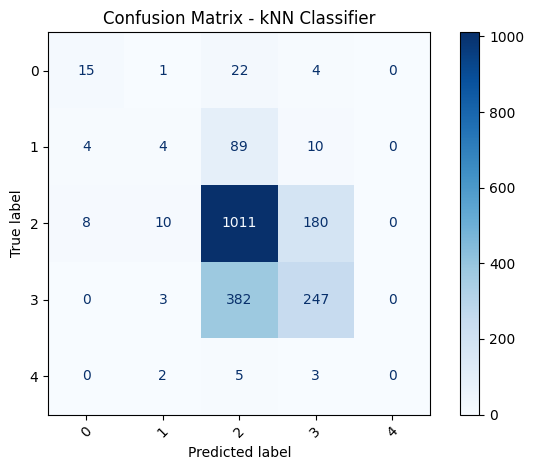

In [ ]:
############################################################

# K-Nearest-Neighbors (WITH FORWARD SELECTION)



################################################################

import numpy as np
import pandas as pd
import string
from sklearn.preprocessing import MinMaxScaler, MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from scipy.sparse import hstack, csr_matrix
import nltk
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

# Downloads (comment out if already done)
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

# Load dataset
df = pd.read_csv('./imdb_movies.csv')
df = df[df['orig_lang'].apply(lambda x: x.isascii())]
df = df.drop_duplicates(subset=['names', 'date_x'])

df['release_date'] = pd.to_datetime(df['date_x'], errors='coerce')
df['release_year'] = df['release_date'].dt.year.fillna(0).astype(int)

df['budget_x'] = pd.to_numeric(df['budget_x'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['budget_normalized'] = MinMaxScaler().fit_transform(df[['budget_x']].fillna(0))
df['revenue_normalized'] = MinMaxScaler().fit_transform(df[['revenue']].fillna(0))

df['genre_list'] = df['genre'].fillna('').apply(lambda x: [g.strip() for g in x.split(',')])

def map_rating(score):
    if pd.isna(score): return np.nan
    score = float(score)
    if score < 30: return 0
    elif score < 50: return 1
    elif score < 70: return 2
    elif score < 85: return 3
    else: return 4

df['rating_class'] = df['score'].apply(map_rating)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text: str):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = ''.join([char for char in text if char.isascii() and char not in string.punctuation])
    tokens = word_tokenize(text)
    lemmatized = [lemmatizer.lemmatize(word) for word in tokens if word.isalpha() and word not in stop_words]
    return " ".join(lemmatized)

df['clean_overview'] = df['overview'].apply(clean_text)

# Feature extraction
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_overview'])

mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(df['genre_list'])
genre_sparse = csr_matrix(genre_matrix)

budget_sparse = csr_matrix(df[['budget_normalized']].fillna(0).values)
revenue_sparse = csr_matrix(df[['revenue_normalized']].fillna(0).values)

# Filter valid labels
valid_rows = df['rating_class'].notna().to_numpy()
df_valid = df.loc[valid_rows].reset_index(drop=True)

X_tfidf_valid = X_tfidf[valid_rows]
genre_sparse_valid = genre_sparse[valid_rows]
budget_sparse_valid = budget_sparse[valid_rows]
revenue_sparse_valid = revenue_sparse[valid_rows]
y = df_valid['rating_class']

# === USE SELECTED FEATURES ONLY ===
# Final selected features: ['tfidf', 'revenue', 'budget', 'genres']
X_selected = hstack([
    X_tfidf_valid,
    revenue_sparse_valid,
    budget_sparse_valid,
    genre_sparse_valid
])

# Convert to dense for kNN
X_dense = X_selected.toarray()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_dense, y, test_size=0.2, random_state=42)

# Train kNN classifier
knn_model = KNeighborsClassifier(n_neighbors=9, metric='euclidean')
knn_model.fit(X_train, y_train)

# Predict
y_pred = knn_model.predict(X_test)

# Inspect a sample
i = 10
movie = df_valid.iloc[y_test.index[i]]
print("Movie Name:", movie['names'])
print("Release Date:", movie['date_x'])
print("Genres:", movie['genre_list'])
print("Budget:", movie['budget_x'])
print("Revenue:", movie['revenue'])
print("Overview:", movie['overview'][:200], "...")
print("Actual Rating Class:", y_test.iloc[i])
print("Predicted Rating Class:", y_pred[i])

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_model.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - kNN Classifier")
plt.tight_layout()
plt.show()


In [ ]:
############################################################

# Logistic Regression (WITHOUT FORWARD SELECTION)




################################################################



import numpy as np
import pandas as pd
import string
from sklearn.preprocessing import MinMaxScaler, MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from scipy.sparse import hstack, csr_matrix
import nltk
from sklearn.preprocessing import MultiLabelBinarizer


# Downloads (comment out if already done)
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

# Load dataset
df = pd.read_csv('./imdb_movies.csv')

# Drop non-ASCII languages elements
df = df[df['orig_lang'].apply(lambda x: x.isascii())]

# Drop duplicates rows
df = df.drop_duplicates(subset=['names', 'date_x'])

# Convert date and extract year
df['release_date'] = pd.to_datetime(df['date_x'], errors='coerce')
df['release_year'] = df['release_date'].dt.year.fillna(0).astype(int)

# Normalize numeric features
df['budget_x'] = pd.to_numeric(df['budget_x'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['budget_normalized'] = MinMaxScaler().fit_transform(df[['budget_x']].fillna(0))
df['revenue_normalized'] = MinMaxScaler().fit_transform(df[['revenue']].fillna(0))

# Process genre list and convert the comma delimited genres into an array of words
df['genre_list'] = df['genre'].fillna('').apply(lambda x: [g.strip() for g in x.split(',')])

# Bin the rating into classes discretization
def map_rating(score):
    if pd.isna(score): return np.nan
    score = float(score)
    if score < 30: return 0
    elif score < 50: return 1
    elif score < 70: return 2
    elif score < 85: return 3
    else: return 4

# apply the discretization to the dataframe
df['rating_class'] = df['score'].apply(map_rating)

# Clean and lemmatize overview text
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))


# cleans up the words for the movie overview descripton and lemmatizes it for more efficient processing
def clean_text(text: str):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = ''.join([char for char in text if char.isascii() and char not in string.punctuation])
    tokens = word_tokenize(text)
    lemmatized = [lemmatizer.lemmatize(word) for word in tokens if word.isalpha() and word not in stop_words]
    return " ".join(lemmatized)

df['clean_overview'] = df['overview'].apply(clean_text)

 # Vectorize the movie description using TF-IDF; turns text like "hero saves world" => [0.21, 0.00, 0.45, ...] across 5000 word features
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_overview'])


# One-hot encode the genre list so each genre becomes a binary column
# e.g., ['Action', 'Comedy'] => [1, 0, 1, 0] for ['Action', 'Adventure', 'Comedy', 'Drama']
mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(df['genre_list'])
genre_sparse = csr_matrix(genre_matrix)

# Convert normalized budget and revenue into sparse format for efficient stacking
# e.g., budget 0.45 => [0.45], revenue 0.88 => [0.88]
budget_sparse = csr_matrix(df[['budget_normalized']].fillna(0).values)
revenue_sparse = csr_matrix(df[['revenue_normalized']].fillna(0).values)


# Extract release year from date and one-hot encode it
# e.g., year 2020 => [0, 0, 1, 0] for ['year_2018', 'year_2019', 'year_2020', 'year_2021']

df['release_date'] = pd.to_datetime(df['date_x'], errors='coerce')
df['release_year'] = df['release_date'].dt.year.fillna(0).astype(int)

year_encoded = pd.get_dummies(df['release_year'], prefix='year')
year_sparse = csr_matrix(year_encoded.values)


# Filter rows with valid labels
valid_rows = df['rating_class'].notna().to_numpy()
df_valid = df.loc[valid_rows].reset_index(drop=True)

# Filter out rows with missing target labels so model only trains on complete data
# Then apply the same mask to each feature matrix to keep everything aligned row-wise
X_tfidf_valid = X_tfidf[valid_rows]
genre_sparse_valid = genre_sparse[valid_rows]
budget_sparse_valid = budget_sparse[valid_rows]
revenue_sparse_valid = revenue_sparse[valid_rows]
#lang_sparse_valid = lang_sparse[valid_rows]
year_sparse_valid = year_sparse[valid_rows]
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 2. Stack all features into one matrix
X = hstack([
    X_tfidf_valid,
    genre_sparse_valid,
    budget_sparse_valid,
    revenue_sparse_valid,
    #lang_sparse_valid,
    year_sparse_valid
])

# 3. Define target variable
y = df_valid['rating_class']

# 4. Split data — capture indices so we can map predictions back
all_indices = np.arange(X.shape[0])

# split into training and testing
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X, y, all_indices, test_size=0.2, random_state=42
)

from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

# 5. Train Logistic Regression with One-vs-Rest strategy
log_reg = OneVsRestClassifier(LogisticRegression(max_iter=1000, solver='lbfgs', class_weight='balanced'))
log_reg.fit(X_train, y_train)

# 6. Predict
y_pred = log_reg.predict(X_test)

# 7. Map back prediction to original movie
# for debugging to see how the model is predicting things
i = 10  # Choose test row to inspect
original_index = test_idx[i]
movie = df_valid.iloc[original_index]

print("Movie Name:", movie['names'])
print("Release Date:", movie['date_x'])
print("Genres:", movie['genre_list'])
print("Budget:", movie['budget_x'])
print("Revenue:", movie['revenue'])
print("Overview:", movie['overview'][:200], "...")
print("Actual Rating Class:", y_test.iloc[i])
print("Predicted Rating Class:", y_pred[i])

# 8. Full performance report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))




[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Movie Name: Rings
Release Date: 05/31/2017 
Genres: ['Horror']
Budget: 25000000.0
Revenue: 82917283.0
Overview: Julia becomes worried about her boyfriend Holt when he explores the dark urban legend of a mysterious videotape said to kill the watcher seven days after viewing. She sacrifices herself to save her bo ...
Actual Rating Class: 2
Predicted Rating Class: 2

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.90      0.55        42
           1       0.19      0.24      0.22       107
           2       0.75      0.63      0.68      1209
           3       0.52      0.62      0.56       632
           4       0.07      0.10      0.08        10

    accuracy                           0.60      2000
   macro avg       0.39      0.50      0.42      2000
weighted avg       0.64      0.60      0.61      2000



In [ ]:
############################################################

# Logistic Regression (WITH FORWARD SELECTION)




################################################################

import numpy as np
import pandas as pd
import string
from sklearn.preprocessing import MinMaxScaler, MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from scipy.sparse import hstack, csr_matrix
import nltk
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report

# Downloads (comment out if already done)
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

# Load dataset
df = pd.read_csv('./imdb_movies.csv')
df = df[df['orig_lang'].apply(lambda x: x.isascii())]
df = df.drop_duplicates(subset=['names', 'date_x'])
df['release_date'] = pd.to_datetime(df['date_x'], errors='coerce')
df['release_year'] = df['release_date'].dt.year.fillna(0).astype(int)

df['budget_x'] = pd.to_numeric(df['budget_x'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['budget_normalized'] = MinMaxScaler().fit_transform(df[['budget_x']].fillna(0))
df['revenue_normalized'] = MinMaxScaler().fit_transform(df[['revenue']].fillna(0))

df['genre_list'] = df['genre'].fillna('').apply(lambda x: [g.strip() for g in x.split(',')])


def map_rating(score):
    if pd.isna(score): return np.nan
    score = float(score)
    if score < 30:
        return 0
    elif score < 50:
        return 1
    elif score < 70:
        return 2
    elif score < 85:
        return 3
    else:
        return 4


df['rating_class'] = df['score'].apply(map_rating)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))


def clean_text(text: str):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = ''.join([char for char in text if char.isascii() and char not in string.punctuation])
    tokens = word_tokenize(text)
    lemmatized = [lemmatizer.lemmatize(word) for word in tokens if word.isalpha() and word not in stop_words]
    return " ".join(lemmatized)


df['clean_overview'] = df['overview'].apply(clean_text)

tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_overview'])

mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(df['genre_list'])
genre_sparse = csr_matrix(genre_matrix)

budget_sparse = csr_matrix(df[['budget_normalized']].fillna(0).values)
revenue_sparse = csr_matrix(df[['revenue_normalized']].fillna(0).values)

df['release_date'] = pd.to_datetime(df['date_x'], errors='coerce')
df['release_year'] = df['release_date'].dt.year.fillna(0).astype(int)
year_encoded = pd.get_dummies(df['release_year'], prefix='year')
year_sparse = csr_matrix(year_encoded.values)

valid_rows = df['rating_class'].notna().to_numpy()
df_valid = df.loc[valid_rows].reset_index(drop=True)

X_tfidf_valid = X_tfidf[valid_rows]
genre_sparse_valid = genre_sparse[valid_rows]
budget_sparse_valid = budget_sparse[valid_rows]
revenue_sparse_valid = revenue_sparse[valid_rows]
year_sparse_valid = year_sparse[valid_rows]

y = df_valid['rating_class']

# === FORWARD SELECTION ===

feature_blocks = {
    'tfidf': X_tfidf_valid,
    'genres': genre_sparse_valid,
    'budget': budget_sparse_valid,
    'revenue': revenue_sparse_valid,
    'year': year_sparse_valid
}

selected = []
remaining = list(feature_blocks.keys())
best_score = 0

print("FORWARD SELECTION STARTED")
while remaining:
    scores = []
    for feat in remaining:
        X_try = hstack([feature_blocks[f] for f in selected + [feat]])
        score = cross_val_score(
            OneVsRestClassifier(LogisticRegression(max_iter=1000, solver='lbfgs', class_weight='balanced')),
            X_try, y, cv=3, scoring='f1_macro'
        ).mean()
        scores.append((feat, score))

    best_feat, best_feat_score = max(scores, key=lambda x: x[1])
    if best_feat_score > best_score:
        selected.append(best_feat)
        remaining.remove(best_feat)
        best_score = best_feat_score
        print("Added: ",best_feat, "(F1 = ",best_feat_score)
    else:
        print("No improvement — stopping selection.")
        break

print("\nFinal selected features:",selected)

X_selected = hstack([feature_blocks[f] for f in selected])
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

model = OneVsRestClassifier(LogisticRegression(max_iter=1000, solver='lbfgs', class_weight='balanced'))
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\nClassification Report (Forward Selection):")
print(classification_report(y_test, y_pred))


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


FORWARD SELECTION STARTED
Added:  tfidf (F1 =  0.2821588548034538
Added:  revenue (F1 =  0.3500425047077706
Added:  budget (F1 =  0.4230298121003135
Added:  genres (F1 =  0.46355003775551534
No improvement — stopping selection.

Final selected features: ['tfidf', 'revenue', 'budget', 'genres']

Classification Report (Forward Selection):
              precision    recall  f1-score   support

           0       0.53      0.71      0.61        42
           1       0.19      0.23      0.21       107
           2       0.74      0.61      0.67      1209
           3       0.50      0.63      0.56       632
           4       0.12      0.10      0.11        10

    accuracy                           0.60      2000
   macro avg       0.42      0.46      0.43      2000
weighted avg       0.63      0.60      0.60      2000



In [1]:
import numpy as np
import pandas as pd
import string
from sklearn.preprocessing import MinMaxScaler, MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from scipy.sparse import hstack, csr_matrix
import nltk
from sklearn.preprocessing import MultiLabelBinarizer


# Downloads (comment out if already done)
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

# Load dataset
df = pd.read_csv('./imdb_movies.csv')

# Drop non-ASCII languages elements
df = df[df['orig_lang'].apply(lambda x: x.isascii())]

# Drop duplicates rows
df = df.drop_duplicates(subset=['names', 'date_x'])

# Convert date and extract year
df['release_date'] = pd.to_datetime(df['date_x'], errors='coerce')
df['release_year'] = df['release_date'].dt.year.fillna(0).astype(int)

# Normalize numeric features
df['budget_x'] = pd.to_numeric(df['budget_x'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['budget_normalized'] = MinMaxScaler().fit_transform(df[['budget_x']].fillna(0))
df['revenue_normalized'] = MinMaxScaler().fit_transform(df[['revenue']].fillna(0))

# Process genre list and convert the comma delimited genres into an array of words
df['genre_list'] = df['genre'].fillna('').apply(lambda x: [g.strip() for g in x.split(',')])

# Bin the rating into classes discretization
def map_rating(score):
    if pd.isna(score): return np.nan
    score = float(score)
    if score < 30: return 0
    elif score < 50: return 1
    elif score < 70: return 2
    elif score < 85: return 3
    else: return 4

# apply the discretization to the dataframe
df['rating_class'] = df['score'].apply(map_rating)

# Clean and lemmatize overview text
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))


# cleans up the words for the movie overview descripton and lemmatizes it for more efficient processing
def clean_text(text: str):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = ''.join([char for char in text if char.isascii() and char not in string.punctuation])
    tokens = word_tokenize(text)
    lemmatized = [lemmatizer.lemmatize(word) for word in tokens if word.isalpha() and word not in stop_words]
    return " ".join(lemmatized)

df['clean_overview'] = df['overview'].apply(clean_text)

 # Vectorize the movie description using TF-IDF; turns text like "hero saves world" => [0.21, 0.00, 0.45, ...] across 5000 word features
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_overview'])


# One-hot encode the genre list so each genre becomes a binary column
# e.g., ['Action', 'Comedy'] => [1, 0, 1, 0] for ['Action', 'Adventure', 'Comedy', 'Drama']
mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(df['genre_list'])
genre_sparse = csr_matrix(genre_matrix)

# Convert normalized budget and revenue into sparse format for efficient stacking
# e.g., budget 0.45 => [0.45], revenue 0.88 => [0.88]
budget_sparse = csr_matrix(df[['budget_normalized']].fillna(0).values)
revenue_sparse = csr_matrix(df[['revenue_normalized']].fillna(0).values)


# Extract release year from date and one-hot encode it
# e.g., year 2020 => [0, 0, 1, 0] for ['year_2018', 'year_2019', 'year_2020', 'year_2021']

df['release_date'] = pd.to_datetime(df['date_x'], errors='coerce')
df['release_year'] = df['release_date'].dt.year.fillna(0).astype(int)

year_encoded = pd.get_dummies(df['release_year'], prefix='year')
year_sparse = csr_matrix(year_encoded.values)


# Filter rows with valid labels
valid_rows = df['rating_class'].notna().to_numpy()
df_valid = df.loc[valid_rows].reset_index(drop=True)

# Filter out rows with missing target labels so model only trains on complete data
# Then apply the same mask to each feature matrix to keep everything aligned row-wise
X_tfidf_valid = X_tfidf[valid_rows]
genre_sparse_valid = genre_sparse[valid_rows]
budget_sparse_valid = budget_sparse[valid_rows]
revenue_sparse_valid = revenue_sparse[valid_rows]
#lang_sparse_valid = lang_sparse[valid_rows]
year_sparse_valid = year_sparse[valid_rows]
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 2. Stack all features into one matrix
X = hstack([
    X_tfidf_valid,
    genre_sparse_valid,
    budget_sparse_valid,
    revenue_sparse_valid,
    #lang_sparse_valid,
    year_sparse_valid
])

# 3. Define target variable
y = df_valid['rating_class']

# 4. Split data — capture indices so we can map predictions back
all_indices = np.arange(X.shape[0])

# split into training and testing
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X, y, all_indices, test_size=0.2, random_state=42
)

from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier

# 5. Train Support Vector Machine with One-vs-Rest strategy
svm_model = OneVsRestClassifier(LinearSVC(C=0.2,class_weight='balanced'))
svm_model.fit(X_train, y_train)

# 6. Predict
y_pred = svm_model.predict(X_test)

# 7. Map back prediction to original movie
i = 10  # Choose test row to inspect
original_index = test_idx[i]
movie = df_valid.iloc[original_index]

print("Movie Name:", movie['names'])
print("Release Date:", movie['date_x'])
print("Genres:", movie['genre_list'])
print("Budget:", movie['budget_x'])
print("Revenue:", movie['revenue'])
print("Overview:", movie['overview'][:200], "...")
print("Actual Rating Class:", y_test.iloc[i])
print("Predicted Rating Class:", y_pred[i])

# 8. Full performance report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Movie Name: Rings
Release Date: 05/31/2017 
Genres: ['Horror']
Budget: 25000000.0
Revenue: 82917283.0
Overview: Julia becomes worried about her boyfriend Holt when he explores the dark urban legend of a mysterious videotape said to kill the watcher seven days after viewing. She sacrifices herself to save her bo ...
Actual Rating Class: 2
Predicted Rating Class: 2

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.83      0.61        42
           1       0.19      0.22      0.21       107
           2       0.73      0.64      0.68      1209
           3       0.52      0.62      0.56       632
           4       0.25      0.10      0.14        10

    accuracy                           0.61      2000
   macro avg       0.44      0.48      0.44      2000
weighted avg       0.63      0.61      0.62      2000

